In [1]:
print("Hello, Satellite Image Analysis!")


Hello, Satellite Image Analysis!


Image type: <class 'PIL.Image.Image'>
Image size: (64, 64)
Label (integer): 0
Label (class name): AnnualCrop


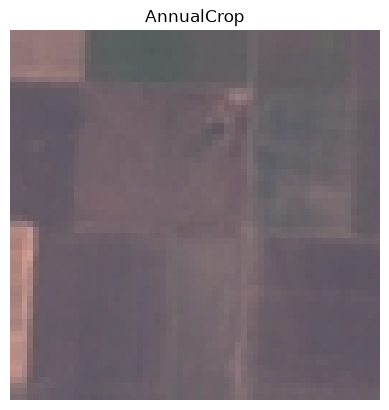

In [2]:
import torchvision
import matplotlib.pyplot as plt

# Load the dataset we already downloaded (download=False since it exists)
dataset = torchvision.datasets.EuroSAT(root="../data/raw", download=False)

# Inspect a single sample
image, label = dataset[0]
print(f"Image type: {type(image)}")
print(f"Image size: {image.size}")   # (width, height) since it's a PIL Image
print(f"Label (integer): {label}")
print(f"Label (class name): {dataset.classes[label]}")

# Display the image
plt.imshow(image)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

In [3]:
import sys
print(sys.executable)


C:\Users\jayva\OneDrive\Desktop\satellite-image-analysis\venv\Scripts\python.exe


In [4]:
from collections import Counter

# Count how many images belong to each class
label_counts = Counter(dataset.targets)

print("Class distribution:")
for class_idx, count in sorted(label_counts.items()):
    class_name = dataset.classes[class_idx]
    print(f"  {class_name:25s}: {count} images")

print(f"\nTotal images: {sum(label_counts.values())}")
print(f"Number of classes: {len(dataset.classes)}")

Class distribution:
  AnnualCrop               : 3000 images
  Forest                   : 3000 images
  HerbaceousVegetation     : 3000 images
  Highway                  : 2500 images
  Industrial               : 2500 images
  Pasture                  : 2000 images
  PermanentCrop            : 2500 images
  Residential              : 3000 images
  River                    : 2500 images
  SeaLake                  : 3000 images

Total images: 27000
Number of classes: 10


In [5]:
sizes = set()
modes = set()

for image, label in dataset:
    sizes.add(image.size)   # (width, height)
    modes.add(image.mode)   # e.g. 'RGB', 'L' (grayscale), etc.

print(f"Unique image sizes found: {sizes}")
print(f"Unique image modes found: {modes}")

Unique image sizes found: {(64, 64)}
Unique image modes found: {'RGB'}


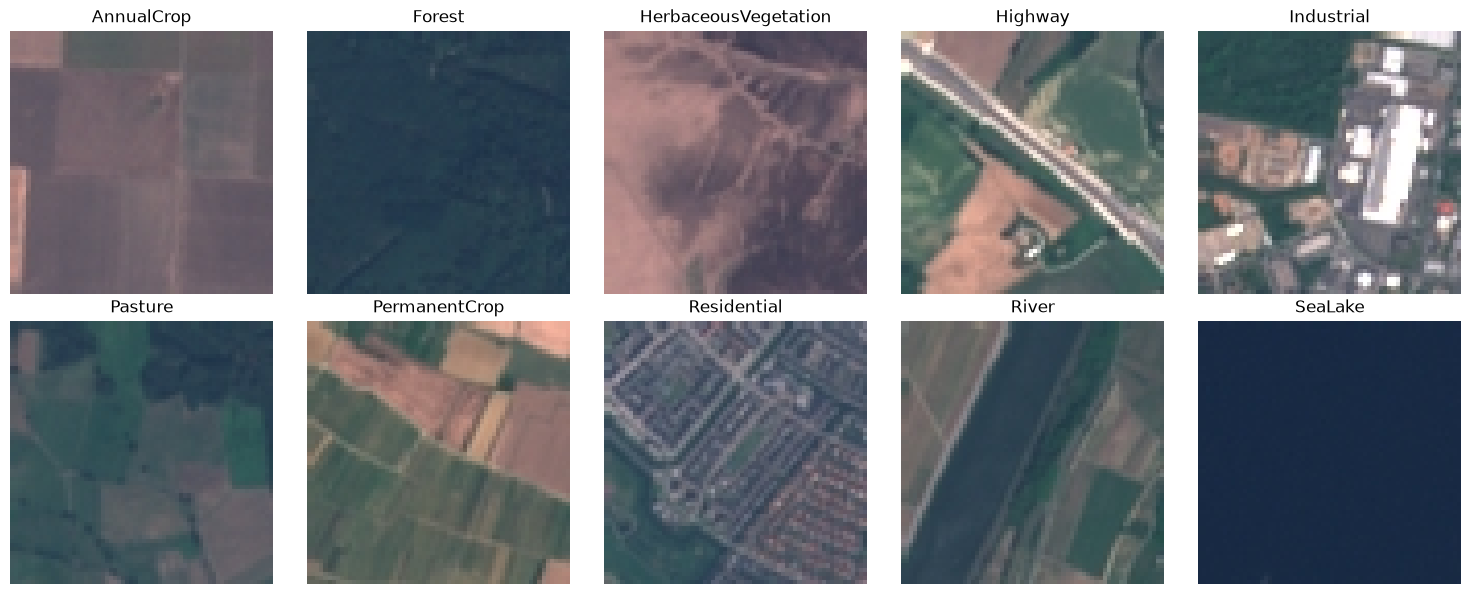

In [6]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
axes = axes.flatten()

seen_classes = {}
for image, label in dataset:
    class_name = dataset.classes[label]
    if class_name not in seen_classes:
        seen_classes[class_name] = image
    if len(seen_classes) == len(dataset.classes):
        break

for idx, (class_name, image) in enumerate(seen_classes.items()):
    axes[idx].imshow(image)
    axes[idx].set_title(class_name)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

In [7]:
import sys
sys.path.append("../src")

from utils import preprocess_image

image, label = dataset[0]
tensor = preprocess_image(image)

print(f"Tensor shape: {tensor.shape}")
print(f"Tensor dtype: {tensor.dtype}")
print(f"Min value: {tensor.min().item():.3f}")
print(f"Max value: {tensor.max().item():.3f}")

Tensor shape: torch.Size([3, 64, 64])
Tensor dtype: torch.float32
Min value: -0.714
Max value: 1.376


In [8]:
sys.path.append("../src")  # if not already added earlier in the notebook
from dataset import EuroSATDataset

eurosat = EuroSATDataset(root="../data/raw")

print(f"Number of samples: {len(eurosat)}")
print(f"Classes: {eurosat.classes}")

tensor, label = eurosat[0]
print(f"Tensor shape: {tensor.shape}")
print(f"Label: {label} -> {eurosat.classes[label]}")

Number of samples: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Tensor shape: torch.Size([3, 64, 64])
Label: 0 -> AnnualCrop


In [9]:
from torch.utils.data import random_split, DataLoader
import torch

# For reproducibility: ensures the "random" split is the same every time
# you re-run this code. Very important for debugging and fair comparisons.
torch.manual_seed(42)

total_size = len(eurosat)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size  # remainder, avoids rounding gaps

train_dataset, val_dataset, test_dataset = random_split(
    eurosat, [train_size, val_size, test_size]
)

print(f"Train size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")
print(f"Test size: {len(test_dataset)}")

# Wrap each split in a DataLoader for batching + shuffling
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Quick check: grab one batch and inspect its shape
images, labels = next(iter(train_loader))
print(f"\nOne batch of images shape: {images.shape}")
print(f"One batch of labels shape: {labels.shape}")

Train size: 18900
Validation size: 4050
Test size: 4050

One batch of images shape: torch.Size([32, 3, 64, 64])
One batch of labels shape: torch.Size([32])


In [10]:
sys.path.append("../src")
from model import SatelliteCNN

model = SatelliteCNN(num_classes=10)
print(model)

# Sanity check: run one batch through the model
images, labels = next(iter(train_loader))
outputs = model(images)
print(f"\nInput batch shape: {images.shape}")
print(f"Output batch shape: {outputs.shape}")

SatelliteCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=10, bias=True)
  )
)

Input batch shape: torch.Size([32, 3, 64, 64])
Output batch shape: torch.Size([32, 10])
